In [1]:
from google.colab import files
uploaded = files.upload()

Saving sales_data (1).csv to sales_data (1).csv


In [2]:
import pandas as pd

df = pd.read_csv('sales_data (1).csv')
df.head()

,Month,Category,Product,UnitsSold,Price,Revenue
0,2025-01,Electronics,Wireless Earbuds,58,111.14,6446.12
1,2025-01,Electronics,Smartphone Case,47,91.81,4315.07
2,2025-01,Electronics,Power Bank,46,13.42,617.32
3,2025-01,Electronics,Bluetooth Speaker,46,130.60,6007.60
4,2025-01,Clothing,T-Shirt,57,7.98,454.86


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Month      240 non-null    object 
 1   Category   240 non-null    object 
 2   Product    240 non-null    object 
 3   UnitsSold  240 non-null    int64  
 4   Price      240 non-null    float64
 5   Revenue    240 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 11.4+ KB


,UnitsSold,Price,Revenue
count,240.000000,240.000000,240.000000
mean,35.704167,79.940750,2874.694000
std,14.113111,44.302468,1960.694025
min,0.000000,5.730000,0.000000
25%,26.000000,44.065000,1198.920000
50%,34.000000,83.900000,2703.570000
75%,44.000000,121.507500,4048.650000
max,86.000000,148.560000,8419.950000


**Question 1: Which product category generates the most revenue?**

In [4]:
cat_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
print(cat_revenue)

Category
Electronics       203591.92
Clothing          140973.07
Beauty            131380.90
Home & Kitchen    126777.87
Books              87202.80
Name: Revenue, dtype: float64


**Finding** : Electronics generates the highest total revenue, approximately 203,592. It is followed by Clothing at 140,973 and Beauty at 131,381. Books generates the least revenue at 87,203, showing Electronics is the strongest-performing category.

**Question 2: Which month had the highest total sales revenue?**

In [5]:
month_revenue = df.groupby('Month')['Revenue'].sum().sort_values(ascending=False)
print(month_revenue)

Month
2025-12    69891.98
2025-07    68984.29
2025-09    65897.49
2025-03    64411.54
2025-06    63917.73
2025-10    62772.35
2025-05    62515.25
2025-11    50877.41
2025-02    48259.05
2025-01    47092.28
2025-08    43683.71
2025-04    41623.48
Name: Revenue, dtype: float64


**Finding**: December had the highest revenue, approximately 69,892. It was followed by July and September. This suggests a seasonal spike, likely due to holiday shopping. April had the lowest revenue, approximately 41,623.

**Question 3: Does a higher price lead to fewer units sold in the Electronics category?**

In [6]:
electronics = df[df['Category'] == 'Electronics']

print(electronics[['Price','UnitsSold']].corr())
print(electronics.groupby('Product')[['Price','UnitsSold']].mean())

              Price  UnitsSold
Price      1.000000  -0.089422
UnitsSold -0.089422   1.000000
                       Price  UnitsSold
Product                                
Bluetooth Speaker  95.610000  43.250000
Power Bank         88.294167  48.666667
Smartphone Case    87.246667  47.250000
Wireless Earbuds   83.119167  55.000000


**Finding:** The correlation between price and units sold is very weak
(-0.089), meaning price does not strongly affect how many units are
sold. Wireless Earbuds sold the most units on average (55) despite a
mid-range price, while Bluetooth Speaker — the most expensive product —
sold the fewest units (43). This suggests demand is driven more by
product type than by price alone.

**Chart: Visualizing revenue by category**

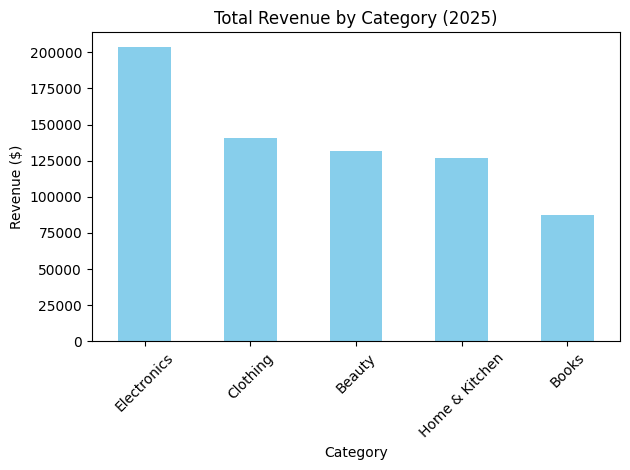

In [7]:
import matplotlib.pyplot as plt

cat_revenue.plot(kind='bar', color='skyblue', title='Total Revenue by Category (2025)')
plt.ylabel('Revenue ($)')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()